# Task 3.2 — YOLO Detection & Segmentation | Transfer Learning
**YOLOv8s-seg, COCO pretrained — Phase 1: frozen backbone (10 epochs) + Phase 2: full fine-tune (30 epochs) = 40 total**

## Step 1 — Install Dependencies

In [1]:
!pip install -q ultralytics scikit-learn huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.6 MB/s eta 0:00:00


## Step 2 — Download & Unzip Dataset

In [ ]:
import json, os
from pathlib import Path
from huggingface_hub import login, hf_hub_download

# ── Sample annotation (one pair) used to bootstrap structure checks ─────────
SAMPLE_ANNOTATION = {
    "source": "user",
    "pair_id": 1,
    "item2": {
        "segmentation": [
            [460,438,374,484,251,520,269,586,298,622,410,623,410,567,413,591,420,623,465,622,456,561,466,504,460,438],
            [374,484,251,520,269,586,298,622,410,623,410,567,374,484],
            [460,438,374,484,410,567,413,591,420,623,465,622,456,561,466,504,460,438]
        ],
        "scale": 2, "viewpoint": 2, "zoom_in": 3,
        "landmarks": [251,520,1,374,484,1,460,438,1,269,586,1,0,0,0,0,0,0,0,0,0,0,0,0,
                      410,567,1,413,591,2,0,0,0,0,0,0,456,561,2,0,0,0],
        "style": 0, "bounding_box": [249,423,466,623],
        "category_id": 8, "occlusion": 2, "category_name": "trousers"
    },
    "item1": {
        "segmentation": [
            [257,35,261,89,228,123,137,103,45,91,1,176,0,332,47,447,151,401,141,366,
             129,328,141,364,219,485,274,603,401,590,467,502,442,336,369,195,348,138,
             363,163,372,197,433,137,396,92,341,35,257,35],
            [1,176,0,332,47,447,151,401,141,366,129,328,1,176],
            [348,138,363,163,372,197,433,137,396,92,341,35,348,138]
        ],
        "scale": 3, "viewpoint": 2, "zoom_in": 2,
        "landmarks": [182,54,1,45,91,1,137,103,1,228,123,1,261,89,1,257,35,1,0,0,0,0,0,0,
                      47,447,2,151,401,2,141,366,2,129,328,2,141,364,2,219,485,2,274,603,2,
                      401,590,2,0,0,0,442,336,2,369,195,1,348,138,1,363,163,1,372,197,1,
                      433,137,2,396,92,2,341,35,1],
        "style": 1, "bounding_box": [0,29,466,622],
        "category_id": 1, "occlusion": 2, "category_name": "short sleeve top"
    }
}

os.makedirs('/kaggle/working', exist_ok=True)
with open('/kaggle/working/sample_annotation.json', 'w') as f:
    json.dump(SAMPLE_ANNOTATION, f, indent=2)

# ── Download dataset from HuggingFace ────────────────────────────────────────
login(token='')

hf_hub_download(repo_id='Harsh2005/DeepFashion2-Pruned', filename='train_clean.zip',
                repo_type='dataset', local_dir='/kaggle/working')
hf_hub_download(repo_id='Harsh2005/DeepFashion2-Pruned', filename='validation_clean.zip',
                repo_type='dataset', local_dir='/kaggle/working')

# train_clean.zip extracts to: /kaggle/working/train/train/{image,annos}
# validation_clean.zip extracts to: /kaggle/working/val/validation/{image,annos}
os.system('unzip -q /kaggle/working/train_clean.zip -d /kaggle/working/train')
os.system('unzip -q /kaggle/working/validation_clean.zip -d /kaggle/working/val')

for f in ['/kaggle/working/train_clean.zip', '/kaggle/working/validation_clean.zip']:
    if os.path.exists(f): os.remove(f)

print('\u2705 Dataset downloaded and extracted!')
print('   Sample annotation saved to /kaggle/working/sample_annotation.json')
print('   Annotation keys:', list(SAMPLE_ANNOTATION.keys()))


train_clean.zip:   0%|          | 0.00/7.99G [00:00<?, ?B/s]

validation_clean.zip:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

✅ Dataset downloaded and extracted!
   Sample annotation saved to /kaggle/working/sample_annotation.json
   Annotation keys: ['source', 'pair_id', 'item2', 'item1']


## Step 3 — Imports & Configuration

In [3]:
import json, shutil, random, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import defaultdict
from PIL import Image, ImageDraw
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

# ── Label map matching instructor's format exactly ───────────────────────────
TOP5_CAT_IDS   = [1, 8, 7, 2, 9]
TOP5_CAT_NAMES = {1: 'short sleeve top', 8: 'trousers', 7: 'shorts',
                   2: 'long sleeve top',  9: 'skirt'}
CAT2YOLO  = {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}
YOLO2NAME = {0: 'short sleeve top', 1: 'trousers', 2: 'shorts',
              3: 'long sleeve top',  4: 'skirt'}

SAMPLES_PER_CLASS = 4000  # 5 classes × 4 000 = 20 000 total samples
YOLO_DIR      = Path('/kaggle/working/yolo_dataset')

# ── Paths matching HuggingFace zip extraction structure ──────────────────────
TRAIN_IMG_SRC = Path('/kaggle/working/train/train/image')
TRAIN_ANN_SRC = Path('/kaggle/working/train/train/annos')
VAL_IMG_SRC   = Path('/kaggle/working/val/validation/image')
VAL_ANN_SRC   = Path('/kaggle/working/val/validation/annos')

label_map = {'short sleeve top': 0, 'trousers': 1, 'shorts': 2,
              'long sleeve top': 3, 'skirt': 4}
with open('/kaggle/working/label_map.json', 'w') as f:
    json.dump(label_map, f, indent=4)

print('\u2705 Config set.')
print(f'   Classes: {list(YOLO2NAME.values())}')
print(f'   label_map.json saved \u2705')


✅ Config set.
   Classes: ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
   label_map.json saved ✅


## Step 3b — Setup Logger

In [4]:
import logging, sys
from datetime import datetime

log_file = '/kaggle/working/training_log_tl.txt'

logger = logging.getLogger('YOLO_TL')
logger.setLevel(logging.INFO)
logger.handlers.clear()

fh = logging.FileHandler(log_file, mode='w')
fh.setLevel(logging.INFO)
ch = logging.StreamHandler(sys.stdout)
ch.setLevel(logging.INFO)

fmt = logging.Formatter(fmt='%(asctime)s | %(levelname)-8s | %(message)s',
                        datefmt='%Y-%m-%d %H:%M:%S')
fh.setFormatter(fmt); ch.setFormatter(fmt)
logger.addHandler(fh); logger.addHandler(ch)

def log_section(title):
    border = '=' * 65
    logger.info(border)
    logger.info(f'  {title}')
    logger.info(border)

def log_table(headers, rows):
    col_w = [max(len(str(h)), max((len(str(r[i])) for r in rows), default=0))
             for i, h in enumerate(headers)]
    logger.info('  ' + '  '.join(str(h).ljust(col_w[i]) for i, h in enumerate(headers)))
    logger.info('  ' + '  '.join('-'*w for w in col_w))
    for row in rows:
        logger.info('  ' + '  '.join(str(v).ljust(col_w[i]) for i, v in enumerate(row)))

log_section('RUN STARTED')
logger.info(f'Timestamp     : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
logger.info(f'Model         : YOLOv8s-seg  (Transfer Learning, 2-phase)')
logger.info(f'Phase 1       : Frozen backbone, 10 epochs')
logger.info(f'Phase 2       : Full fine-tune, 30 epochs')
logger.info(f'Total epochs  : 40  (same as Scratch for fair comparison)')
logger.info(f'Log file      : {log_file}')
logger.info(f'Classes       : {list(YOLO2NAME.values())}')
logger.info(f'Samples/class : {SAMPLES_PER_CLASS}  (total ≈ {SAMPLES_PER_CLASS * 5:,})')
print(f'\n📋 Logger ready — saving to {log_file}')

2026-03-31 02:46:09 | INFO     | =================================================================
2026-03-31 02:46:09 | INFO     |   RUN STARTED
2026-03-31 02:46:09 | INFO     | =================================================================
2026-03-31 02:46:09 | INFO     | Timestamp     : 2026-03-31 02:46:09
2026-03-31 02:46:09 | INFO     | Model         : YOLOv8s-seg  (Transfer Learning, 2-phase)
2026-03-31 02:46:09 | INFO     | Phase 1       : Frozen backbone, 10 epochs
2026-03-31 02:46:09 | INFO     | Phase 2       : Full fine-tune, 30 epochs
2026-03-31 02:46:09 | INFO     | Total epochs  : 40  (same as Scratch for fair comparison)
2026-03-31 02:46:09 | INFO     | Log file      : /kaggle/working/training_log_tl.txt
2026-03-31 02:46:09 | INFO     | Classes       : ['short sleeve top', 'trousers', 'shorts', 'long sleeve top', 'skirt']
2026-03-31 02:46:09 | INFO     | Samples/class : 4000  (total ≈ 20,000)

📋 Logger ready — saving to /kaggle/working/training_log_tl.txt


## Step 4 — Parse Annotations & Scan Dataset

In [5]:
def parse_annotation(ann_path, img_path):
    try:
        with open(ann_path) as f: data = json.load(f)
        img_w, img_h = Image.open(img_path).size
    except: return []
    items = []
    for key, val in data.items():
        if not key.startswith('item'): continue
        cat_id = val.get('category_id')
        if cat_id not in TOP5_CAT_IDS: continue
        bbox = val.get('bounding_box')
        segs = val.get('segmentation', [])
        if bbox is None or len(segs) == 0: continue
        items.append({'category_id': cat_id, 'bbox': bbox,
                      'segmentation': segs, 'img_w': img_w, 'img_h': img_h})
    return items

def scan_split(img_dir, ann_dir):
    image_items   = defaultdict(list)
    class_to_imgs = defaultdict(set)
    ann_files = sorted(ann_dir.glob('*.json'))
    print(f'  Scanning {len(ann_files)} files in {ann_dir.name} ...')
    for ann_path in tqdm(ann_files):
        stem     = ann_path.stem
        img_path = img_dir / f'{stem}.jpg'
        if not img_path.exists(): continue
        items = parse_annotation(ann_path, img_path)
        if not items: continue
        image_items[stem].extend(items)
        for it in items: class_to_imgs[it['category_id']].add(stem)
    return image_items, class_to_imgs

print('📂 Scanning TRAIN split ...')
train_image_items, train_class_imgs = scan_split(TRAIN_IMG_SRC, TRAIN_ANN_SRC)
print('\n📂 Scanning VAL split ...')
val_image_items, val_class_imgs = scan_split(VAL_IMG_SRC, VAL_ANN_SRC)

log_section('DATASET SCAN')
rows = []
for cat_id in TOP5_CAT_IDS:
    n_tr = sum(1 for its in train_image_items.values() for it in its if it['category_id']==cat_id)
    n_vl = sum(1 for its in val_image_items.values()   for it in its if it['category_id']==cat_id)
    rows.append((TOP5_CAT_NAMES[cat_id], n_tr, n_vl))
log_table(['Category', 'Train Items', 'Val Items'], rows)

📂 Scanning TRAIN split ...
  Scanning 144174 files in annos ...


100%|██████████| 144174/144174 [00:35<00:00, 4035.69it/s]



📂 Scanning VAL split ...
  Scanning 23741 files in annos ...


100%|██████████| 23741/23741 [00:07<00:00, 3252.48it/s]

2026-03-31 02:46:54 | INFO     | =================================================================
2026-03-31 02:46:54 | INFO     |   DATASET SCAN
2026-03-31 02:46:54 | INFO     | =================================================================


2026-03-31 02:46:55 | INFO     |   Category          Train Items  Val Items
2026-03-31 02:46:55 | INFO     |   ----------------  -----------  ---------
2026-03-31 02:46:55 | INFO     |   short sleeve top  71645        12556    
2026-03-31 02:46:55 | INFO     |   trousers          55387        9586     
2026-03-31 02:46:55 | INFO     |   shorts            36616        4167     
2026-03-31 02:46:55 | INFO     |   long sleeve top   36064        5966     
2026-03-31 02:46:55 | INFO     |   skirt             30835        6522     


In [6]:
print("Actual counts per class after scanning:")
for cat_id in TOP5_CAT_IDS:
    count = sum(1 for items in train_image_items.values() 
                for it in items if it['category_id'] == cat_id)
    print(f"  {TOP5_CAT_NAMES[cat_id]:20s}: {count:,}")

Actual counts per class after scanning:
  short sleeve top    : 71,645
  trousers            : 55,387
  shorts              : 36,616
  long sleeve top     : 36,064
  skirt               : 30,835


## Step 5 — Generate Dataset Splits (in-memory)
Split the scanned image stems into train / val / test (85 / 10 / 5) using the same seed as the Scratch notebook.

In [7]:
import json, random
from collections import defaultdict

random.seed(42)

# ── Step 1: group stems by class ─────────────────────────────────────────────
cat_stems = defaultdict(list)
for stem, items in train_image_items.items():
    for it in items:
        if it['category_id'] in TOP5_CAT_IDS:
            cat_stems[it['category_id']].append(stem)

# ── Step 2: oversample minority, undersample majority ────────────────────────
TARGET = SAMPLES_PER_CLASS  # 4000
balanced_stems = set()
for cat_id, stems in cat_stems.items():
    stems = list(set(stems))  # deduplicate
    if len(stems) >= TARGET:
        balanced_stems.update(random.sample(stems, TARGET))
    else:
        # oversample with replacement for minority classes
        balanced_stems.update(random.choices(stems, k=TARGET))
        logger.info(f"  ⚠️  {TOP5_CAT_NAMES[cat_id]:20s}: only {len(stems)} samples, "
                    f"oversampled to {TARGET}")

all_stems = sorted(balanced_stems)
random.shuffle(all_stems)

# ── Step 3: stratified split ─────────────────────────────────────────────────
class_to_stems = defaultdict(list)
for stem in all_stems:
    for it in train_image_items.get(stem, []):
        if it['category_id'] in TOP5_CAT_IDS:
            class_to_stems[it['category_id']].append(stem)
            break

train_set, val_set, test_set = set(), set(), set()
for cat_id, stems in class_to_stems.items():
    stems = list(set(stems))
    random.shuffle(stems)
    n    = len(stems)
    n_tr = int(n * 0.85)
    n_vl = int(n * 0.10)
    train_set.update(stems[:n_tr])
    val_set.update(stems[n_tr:n_tr + n_vl])
    test_set.update(stems[n_tr + n_vl:])

stems_train = list(train_set)
stems_val   = list(val_set   - train_set)
stems_test  = list(test_set  - train_set - val_set)

# ── Save splits ───────────────────────────────────────────────────────────────
splits = {'train': stems_train, 'val': stems_val, 'test': stems_test}
with open('/kaggle/working/dataset_splits.json', 'w') as f:
    json.dump(splits, f)

log_section('DATA SPLITS  (balanced + stratified, seed=42)')
logger.info(f'Total balanced stems : {len(all_stems)}')
logger.info(f'Train images         : {len(stems_train)}  (~85%)')
logger.info(f'Val   images         : {len(stems_val)}   (~10%)')
logger.info(f'Test  images         : {len(stems_test)}    (~5%)')

2026-03-31 02:46:55 | INFO     | =================================================================
2026-03-31 02:46:55 | INFO     |   DATA SPLITS  (balanced + stratified, seed=42)
2026-03-31 02:46:55 | INFO     | =================================================================
2026-03-31 02:46:55 | INFO     | Total balanced stems : 19380
2026-03-31 02:46:55 | INFO     | Train images         : 16471  (~85%)
2026-03-31 02:46:55 | INFO     | Val   images         : 1936   (~10%)
2026-03-31 02:46:55 | INFO     | Test  images         : 973    (~5%)


## Step 6 — Convert to YOLO Format & Build Dataset

In [8]:
def seg_to_yolo(seg_polygons, img_w, img_h):
    best = max(seg_polygons, key=lambda p: len(p))
    coords = []
    for i in range(0, len(best)-1, 2):
        coords.extend([float(np.clip(best[i]/img_w, 0, 1)),
                        float(np.clip(best[i+1]/img_h, 0, 1))])
    return coords

def write_yolo_label(label_path, items, img_w, img_h):
    lines = []
    for it in items:
        if it['category_id'] not in CAT2YOLO: continue
        coords = seg_to_yolo(it['segmentation'], img_w, img_h)
        if len(coords) < 6: continue
        lines.append(f"{CAT2YOLO[it['category_id']]} " + ' '.join(f'{v:.6f}' for v in coords))
    label_path.write_text('\n'.join(lines))

def build_yolo_split(stems, image_items, img_src_dir, split_name):
    img_dst = YOLO_DIR / split_name / 'images'
    lbl_dst = YOLO_DIR / split_name / 'labels'
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)
    skipped = 0
    for stem in tqdm(stems, desc=f'  {split_name}'):
        src = img_src_dir / f'{stem}.jpg'
        items = image_items.get(stem, [])
        if not src.exists() or not items: skipped += 1; continue
        shutil.copy(src, img_dst / f'{stem}.jpg')
        write_yolo_label(lbl_dst / f'{stem}.txt', items, items[0]['img_w'], items[0]['img_h'])
    logger.info(f'  {split_name:6s}: {len(stems)-skipped} written, {skipped} skipped')

log_section('BUILDING YOLO DATASET')
build_yolo_split(stems_train, train_image_items, TRAIN_IMG_SRC, 'train')
build_yolo_split(stems_val,   train_image_items, TRAIN_IMG_SRC, 'val')
build_yolo_split(stems_test,  val_image_items,   VAL_IMG_SRC,   'test')

2026-03-31 02:46:55 | INFO     | =================================================================
2026-03-31 02:46:55 | INFO     |   BUILDING YOLO DATASET
2026-03-31 02:46:55 | INFO     | =================================================================


  train: 100%|██████████| 16471/16471 [00:10<00:00, 1536.20it/s]

2026-03-31 02:47:06 | INFO     |   train : 16471 written, 0 skipped



  val: 100%|██████████| 1936/1936 [00:01<00:00, 1579.66it/s]

2026-03-31 02:47:07 | INFO     |   val   : 1936 written, 0 skipped



  test: 100%|██████████| 973/973 [00:00<00:00, 4950.07it/s]

2026-03-31 02:47:07 | INFO     |   test  : 122 written, 851 skipped


## Step 7 — Write data.yaml & Compute Class Weights

In [9]:
yaml_content = (
    f'path: {YOLO_DIR}\ntrain: train/images\nval:   val/images\n\n'
    f'nc: {len(TOP5_CAT_IDS)}\nnames: {[TOP5_CAT_NAMES[c] for c in TOP5_CAT_IDS]}\n'
)
yaml_path = YOLO_DIR / 'data.yaml'
yaml_path.write_text(yaml_content)

test_yaml_path = YOLO_DIR / 'data_test.yaml'
test_yaml_path.write_text(yaml_content.replace('val:   val/images', 'val:   test/images'))

def count_instances(split):
    counts = defaultdict(int)
    for lbl in (YOLO_DIR/split/'labels').glob('*.txt'):
        for line in lbl.read_text().strip().splitlines():
            if line: counts[int(line.split()[0])] += 1
    return counts

train_counts = count_instances('train')
total = sum(train_counts.values())
raw_w = [total / (len(TOP5_CAT_IDS) * (train_counts[i]+1e-6)) for i in range(len(TOP5_CAT_IDS))]
CLASS_WEIGHTS = [w/max(raw_w) for w in raw_w]

log_section('CLASS WEIGHTS (inverse frequency)')
rows = [(YOLO2NAME[i], train_counts[i], f'{CLASS_WEIGHTS[i]:.4f}') for i in range(len(TOP5_CAT_IDS))]
log_table(['Class', 'Train Instances', 'Weight'], rows)
logger.info('data.yaml and data_test.yaml written ✅')

2026-03-31 02:47:08 | INFO     | =================================================================
2026-03-31 02:47:08 | INFO     |   CLASS WEIGHTS (inverse frequency)
2026-03-31 02:47:08 | INFO     | =================================================================
2026-03-31 02:47:08 | INFO     |   Class             Train Instances  Weight
2026-03-31 02:47:08 | INFO     |   ----------------  ---------------  ------
2026-03-31 02:47:08 | INFO     |   short sleeve top  8078             0.5853
2026-03-31 02:47:08 | INFO     |   trousers          5953             0.7942
2026-03-31 02:47:08 | INFO     |   shorts            4745             0.9964
2026-03-31 02:47:08 | INFO     |   long sleeve top   5440             0.8691
2026-03-31 02:47:08 | INFO     |   skirt             4728             1.0000
2026-03-31 02:47:08 | INFO     | data.yaml and data_test.yaml written ✅


## Step 8 — Sanity Check: Visualise Sample Annotations

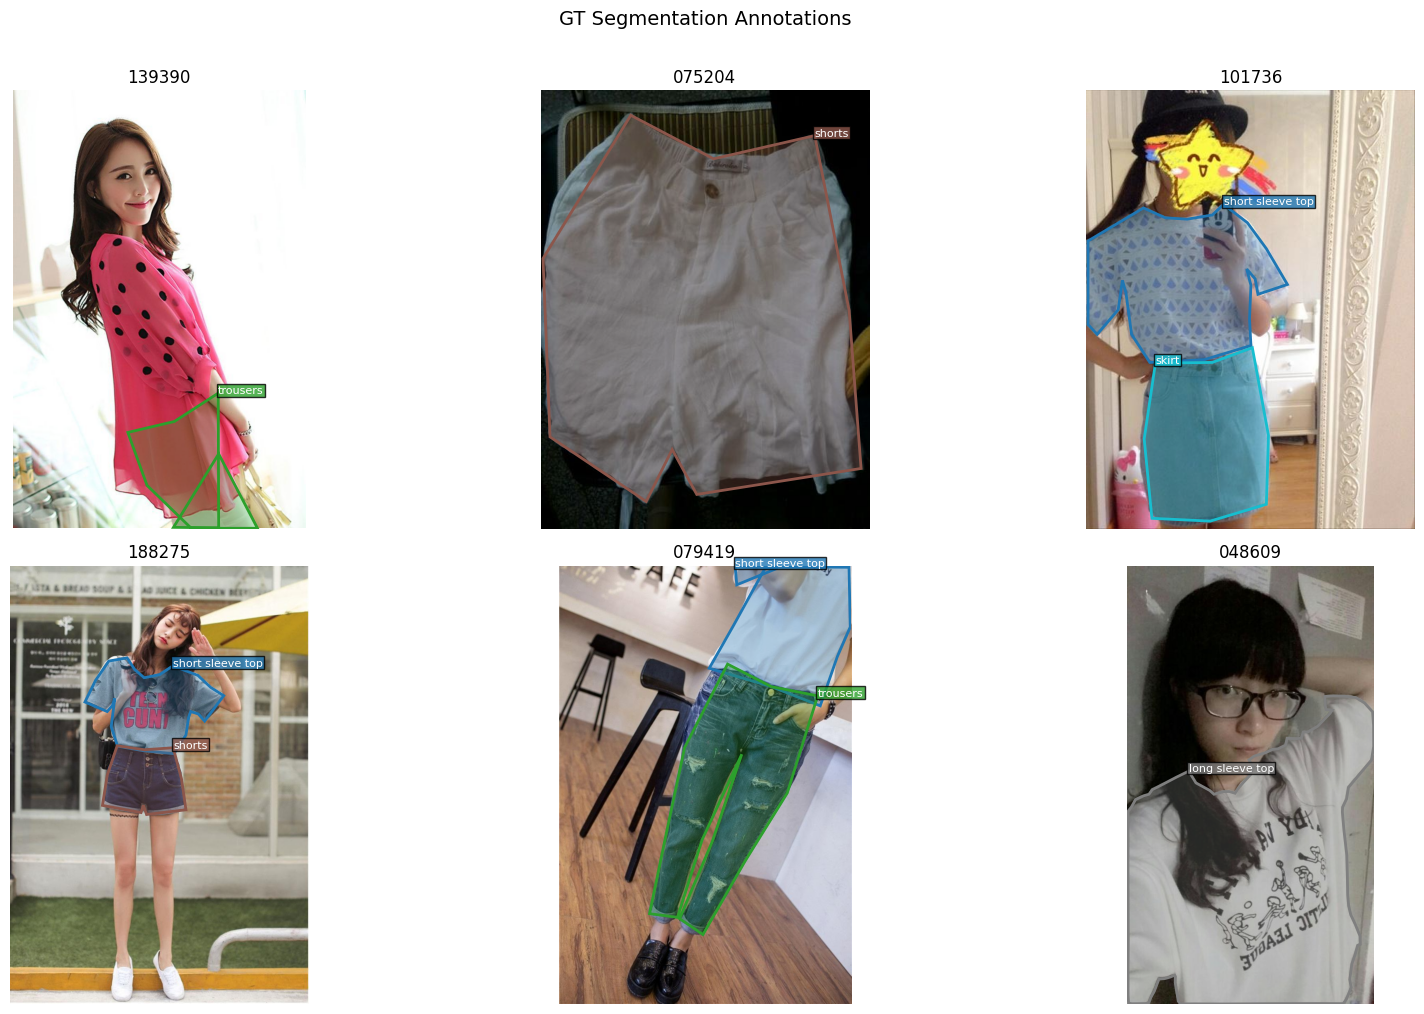

2026-03-31 02:47:10 | INFO     | Sample annotations visualised → sample_annotations_tl.png


In [10]:
img_dir = YOLO_DIR/'train'/'images'
lbl_dir = YOLO_DIR/'train'/'labels'
samples = random.sample(sorted(img_dir.glob('*.jpg')), 6)
colors  = plt.cm.tab10(np.linspace(0,1,len(TOP5_CAT_IDS)))

fig, axes = plt.subplots(2, 3, figsize=(18,10))
for ax, ip in zip(axes.flatten(), samples):
    img = np.array(Image.open(ip))
    W, H = img.shape[1], img.shape[0]
    ax.imshow(img)
    lbl = lbl_dir/(ip.stem+'.txt')
    if lbl.exists():
        for line in lbl.read_text().strip().splitlines():
            if not line: continue
            p = list(map(float,line.split()))
            ci = int(p[0]); c = p[1:]
            xs=[c[i]*W for i in range(0,len(c),2)]; ys=[c[i]*H for i in range(1,len(c),2)]
            ax.add_patch(plt.Polygon(list(zip(xs,ys)), fill=True,
                facecolor=(*colors[ci][:3],0.3), edgecolor=colors[ci][:3], linewidth=2))
            ax.text(xs[0],ys[0],YOLO2NAME[ci],color='white',fontsize=8,
                    bbox=dict(facecolor=colors[ci][:3],alpha=0.8,pad=1))
    ax.axis('off'); ax.set_title(ip.stem)

plt.suptitle('GT Segmentation Annotations', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/sample_annotations_tl.png', dpi=100, bbox_inches='tight')
plt.show()
logger.info('Sample annotations visualised → sample_annotations_tl.png')

## Step 9 — Class Distribution Plot

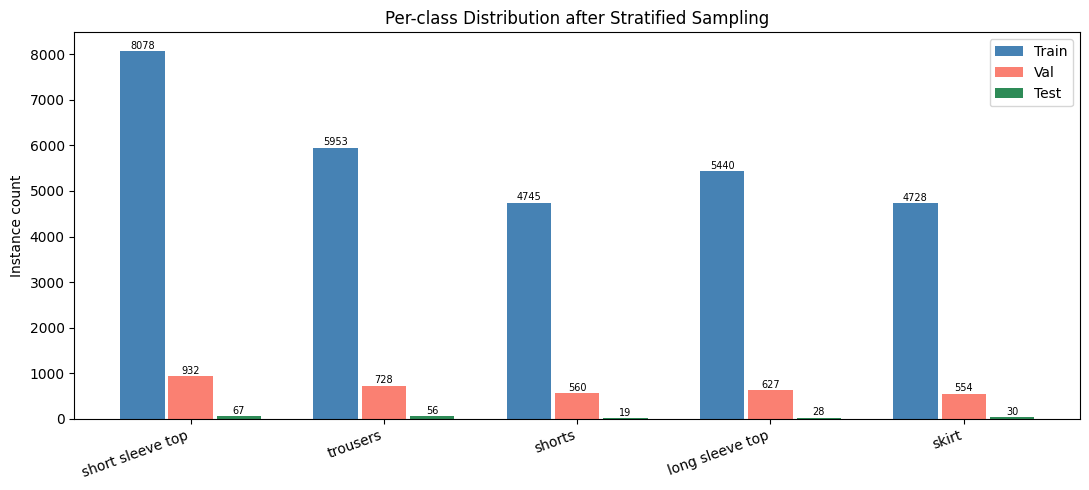

2026-03-31 02:47:11 | INFO     | =================================================================
2026-03-31 02:47:11 | INFO     |   INSTANCE DISTRIBUTION
2026-03-31 02:47:11 | INFO     | =================================================================
2026-03-31 02:47:11 | INFO     |   Class             Train  Val  Test
2026-03-31 02:47:11 | INFO     |   ----------------  -----  ---  ----
2026-03-31 02:47:11 | INFO     |   short sleeve top  8078   932  67  
2026-03-31 02:47:11 | INFO     |   trousers          5953   728  56  
2026-03-31 02:47:11 | INFO     |   shorts            4745   560  19  
2026-03-31 02:47:11 | INFO     |   long sleeve top   5440   627  28  
2026-03-31 02:47:11 | INFO     |   skirt             4728   554  30  


In [11]:
val_counts  = count_instances('val')
test_counts = count_instances('test')
labels = [YOLO2NAME[i] for i in range(len(TOP5_CAT_IDS))]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(11,5))
for offset, counts, label, color in [
    (-0.25, train_counts, 'Train', 'steelblue'),
    ( 0.00, val_counts,   'Val',   'salmon'),
    ( 0.25, test_counts,  'Test',  'seagreen')]:
    bars = ax.bar(x+offset, [counts[i] for i in range(len(labels))], 0.23, label=label, color=color)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
                str(b.get_height()), ha='center', va='bottom', fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Instance count')
ax.set_title('Per-class Distribution after Stratified Sampling')
ax.legend(); plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution_tl.png', dpi=100)
plt.show()

log_section('INSTANCE DISTRIBUTION')
rows = [(YOLO2NAME[i], train_counts[i], val_counts[i], test_counts[i]) for i in range(len(TOP5_CAT_IDS))]
log_table(['Class', 'Train', 'Val', 'Test'], rows)

## Step 10a — Phase 1: Transfer Learning with Frozen Backbone (10 epochs)
COCO pretrained weights loaded. First 10 backbone layers frozen — only detection and segmentation heads train. Warm-up phase.

In [12]:
from ultralytics import YOLO

log_section('PHASE 1 — FROZEN BACKBONE  (YOLOv8s-seg, 10 epochs)')
logger.info('Backbone      : Frozen (first 10 layers)')
logger.info('Epochs        : 10  (warm-up)')
logger.info('Optimizer     : AdamW  |  lr0=1e-3  |  cos_lr=True')
logger.info('Purpose       : Adapt heads to DeepFashion2 before unfreezing')

# ── Resume from last.pt if a previous Phase 1 run was interrupted ────────────
P1_LAST   = '/kaggle/working/runs/tl_phase1/weights/last.pt'
P1_RESUME = Path(P1_LAST).exists()

if P1_RESUME:
    logger.info(f'⚡ Resuming Phase 1 from existing last.pt: {P1_LAST}')
    model_p1 = YOLO(P1_LAST)
    results_p1 = model_p1.train(resume=True)
else:
    model_p1 = YOLO('yolov8s-seg.pt')   # COCO pretrained
    results_p1 = model_p1.train(
        data         = str(yaml_path),
        epochs       = 10,
        patience     = 5,
        imgsz        = 640,
        batch        = 16,
        workers      = 2,
        optimizer    = 'AdamW',
        lr0          = 1e-3,
        weight_decay = 1e-4,
        cos_lr       = True,
        freeze       = 10,
        hsv_h        = 0.015,
        hsv_s        = 0.7,
        hsv_v        = 0.4,
        fliplr       = 0.5,
        mosaic       = 1.0,
        cls          = 0.5,
        project      = '/kaggle/working/runs',
        name         = 'tl_phase1',
        save         = True,
        save_period  = 2,        # checkpoint every 2 epochs
        plots        = True,
        verbose      = True,
    )

P1_BEST = str(Path(model_p1.trainer.save_dir) / 'weights' / 'best.pt')

# ── Backup Phase 1 best so Phase 2 can't overwrite it ───────────────────────
shutil.copy(P1_BEST, '/kaggle/working/best_phase1.pt')  # already there
shutil.copy(str(Path(model_p1.trainer.save_dir)/'weights'/'last.pt'),
            '/kaggle/working/last_phase1.pt')  # ← add this
logger.info(f'Phase 1 best backed up → /kaggle/working/best_phase1.pt')

log_section('PHASE 1 COMPLETE')
logger.info(f'Epochs run    : {model_p1.trainer.epoch + 1} / 10')
logger.info(f'Best weights  : {P1_BEST}')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
2026-03-31 02:47:28 | INFO     | =================================================================
2026-03-31 02:47:28 | INFO     |   PHASE 1 — FROZEN BACKBONE  (YOLOv8s-seg, 10 epochs)
2026-03-31 02:47:28 | INFO     | =================================================================
2026-03-31 02:47:28 | INFO     | Backbone      : Frozen (first 10 layers)
2026-03-31 02:47:28 | INFO     | Epochs        : 10  (warm-up)
2026-03-31 02:47:28 | INFO     | Optimizer     : AdamW  |  lr0=1e-3  |  cos_lr=True
2026-03-31 02:47:28 | INFO     | Purpose       : Adapt heads to DeepFashion2 before unfreezing
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engin

## Step 10b — Phase 2: Full Fine-tuning (30 epochs)
Resume from Phase 1 best weights. Unfreeze all layers. Lower learning rate for careful fine-tuning.
**Phase 1 (10) + Phase 2 (30) = 40 total epochs — same as Scratch for fair comparison.**

In [13]:
log_section('PHASE 2 — FULL FINE-TUNE  (30 epochs, all layers unfrozen)')
logger.info('Backbone      : Unfrozen (all layers)')
logger.info('Epochs        : 30  (fine-tune)')
logger.info('Optimizer     : AdamW  |  lr0=1e-4  |  cos_lr=True')
logger.info('Resume from   : Phase 1 best weights')

# ── Resume from last.pt if a previous Phase 2 run was interrupted ────────────
P2_LAST   = '/kaggle/working/runs/tl_phase2/weights/last.pt'
P2_RESUME = Path(P2_LAST).exists()

if P2_RESUME:
    logger.info(f'⚡ Resuming Phase 2 from existing last.pt: {P2_LAST}')
    model_p2 = YOLO(P2_LAST)
    results_p2 = model_p2.train(resume=True)
else:
    model_p2 = YOLO(P1_BEST)   # start from Phase 1 best
    results_p2 = model_p2.train(
        data         = str(yaml_path),
        epochs       = 30,
        patience     = 10,
        imgsz        = 640,
        batch        = 16,
        workers      = 2,
        optimizer    = 'AdamW',
        lr0          = 1e-4,
        weight_decay = 1e-4,
        cos_lr       = True,
        # no freeze — all layers train
        hsv_h        = 0.015,
        hsv_s        = 0.7,
        hsv_v        = 0.4,
        degrees      = 10,
        translate    = 0.1,
        scale        = 0.5,
        shear        = 2.0,
        fliplr       = 0.5,
        flipud       = 0.0,
        mosaic       = 1.0,
        mixup        = 0.2,
        copy_paste   = 0.3,
        cls          = 0.5,
        project      = '/kaggle/working/runs',
        name         = 'tl_phase2',
        save         = True,
        save_period  = 2,        # checkpoint every 2 epochs
        plots        = True,
        verbose      = True,
    )

P2_BEST = str(Path(model_p2.trainer.save_dir) / 'weights' / 'best.pt')
shutil.copy(str(Path(model_p2.trainer.save_dir)/'weights'/'last.pt'),
            '/kaggle/working/last_phase2.pt') 

log_section('PHASE 2 COMPLETE — TRAINING DONE')
logger.info(f'Epochs run    : {model_p2.trainer.epoch + 1} / 30')
logger.info(f'Total epochs  : ~{1 + model_p2.trainer.epoch + 1} / 30')
logger.info(f'Phase 2 best  : {P2_BEST}')


2026-03-31 03:35:33 | INFO     | =================================================================
2026-03-31 03:35:33 | INFO     |   PHASE 2 — FULL FINE-TUNE  (30 epochs, all layers unfrozen)
2026-03-31 03:35:33 | INFO     | =================================================================
2026-03-31 03:35:33 | INFO     | Backbone      : Unfrozen (all layers)
2026-03-31 03:35:33 | INFO     | Epochs        : 30  (fine-tune)
2026-03-31 03:35:33 | INFO     | Optimizer     : AdamW  |  lr0=1e-4  |  cos_lr=True
2026-03-31 03:35:33 | INFO     | Resume from   : Phase 1 best weights
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=10, 

## Step 10c — Select Best Model Across Both Phases

In [14]:
# ── Select globally best checkpoint across both phases ───────────────────────
log_section('BEST MODEL SELECTION')

p1_path = '/kaggle/working/best_phase1.pt'
p2_path = P2_BEST

m1 = YOLO(p1_path).val(data=str(yaml_path), imgsz=640, batch=16, verbose=False)
m2 = YOLO(p2_path).val(data=str(yaml_path), imgsz=640, batch=16, verbose=False)

logger.info(f'Phase 1 best — Box mAP@0.5: {m1.box.map50:.4f}  |  Seg mAP@0.5: {m1.seg.map50:.4f}')
logger.info(f'Phase 2 best — Box mAP@0.5: {m2.box.map50:.4f}  |  Seg mAP@0.5: {m2.seg.map50:.4f}')

if m1.box.map50 >= m2.box.map50:
    BEST_PT = p1_path
    logger.info(f'✅ Phase 1 selected as global best (mAP50={m1.box.map50:.4f})')
else:
    BEST_PT = p2_path
    logger.info(f'✅ Phase 2 selected as global best (mAP50={m2.box.map50:.4f})')

shutil.copy(BEST_PT, '/kaggle/working/best_tl.pt')
logger.info(f'Global best saved → /kaggle/working/best_tl.pt')


2026-03-31 06:53:01 | INFO     | =================================================================
2026-03-31 06:53:01 | INFO     |   BEST MODEL SELECTION
2026-03-31 06:53:01 | INFO     | =================================================================
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,781,535 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1466.8±554.7 MB/s, size: 49.0 KB)
val: Scanning /kaggle/working/yolo_dataset/val/labels.cache... 1936 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1936/1936 812.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 121/121 4.4it/s 27.5s
                   all       1936       3401      0.848      0.869      0.925      0.788       0.84      0.862      0.913      0.693
Speed: 0.7ms preprocess, 8.7ms inferen

## Step 11 — Detection Metrics: COCO mAP@[0.5:0.95] per class (on Test Set)

In [15]:
# ── Pre-Evaluation Setup: Rebuild test set using full HF validation folder ──
import shutil, json
from pathlib import Path

# BEST_PT is already set from training (Cell 28) — no reload needed
assert Path(BEST_PT).exists(), f"Model not found: {BEST_PT}"
print(f'✅ Using model: {BEST_PT}')

# ── Source: full HuggingFace validation folder ────────────────────────────────
ANNO_SRC = VAL_ANN_SRC   # /kaggle/working/val/validation/annos
IMG_SRC  = VAL_IMG_SRC   # /kaggle/working/val/validation/image

# ── Collect ALL stems with at least one TOP5 category ────────────────────────
stems_test = []
skipped    = 0

for anno_file in tqdm(sorted(ANNO_SRC.glob('*.json')), desc='  scanning annotations'):
    stem = anno_file.stem
    img_path = IMG_SRC / f'{stem}.jpg'
    if not img_path.exists():
        skipped += 1
        continue
    try:
        anno = json.loads(anno_file.read_text())
    except Exception:
        skipped += 1
        continue

    has_top5 = any(
        item.get('category_id') in TOP5_CAT_IDS
        for key, item in anno.items()
        if isinstance(item, dict) and 'category_id' in item
    )
    if has_top5:
        stems_test.append(stem)

print(f'✅ Total images with TOP5 classes found : {len(stems_test)}')
print(f'   Skipped (missing image or bad anno)  : {skipped}')

# ── Write test images + labels to disk ───────────────────────────────────────
test_img_dst = YOLO_DIR / 'test' / 'images'
test_lbl_dst = YOLO_DIR / 'test' / 'labels'
shutil.rmtree(YOLO_DIR / 'test', ignore_errors=True)
test_img_dst.mkdir(parents=True, exist_ok=True)
test_lbl_dst.mkdir(parents=True, exist_ok=True)

written = 0; write_skipped = 0
for stem in tqdm(stems_test, desc='  building test split'):
    src     = IMG_SRC  / f'{stem}.jpg'
    anno_fp = ANNO_SRC / f'{stem}.json'
    if not src.exists() or not anno_fp.exists():
        write_skipped += 1
        continue

    anno  = json.loads(anno_fp.read_text())
    items = [
        item for key, item in anno.items()
        if isinstance(item, dict) and item.get('category_id') in TOP5_CAT_IDS
    ]
    if not items:
        write_skipped += 1
        continue

    shutil.copy(src, test_img_dst / f'{stem}.jpg')
    img_w, img_h = Image.open(src).size
    write_yolo_label(test_lbl_dst / f'{stem}.txt', items, img_w, img_h)
    written += 1

print(f'✅ Test split written : {written} images')
print(f'   Skipped            : {write_skipped} images')
print(f'\n  ▶  TESTING ON {written} IMAGES ACROSS TOP-5 CLASSES (full validation set, no cap)')

# ── Per-class instance count ──────────────────────────────────────────────────
test_counts = count_instances('test')
print(f'\n  {"Class":22s}  {"Instances":>10s}')
print('  ' + '-' * 35)
total_instances = 0
for i in range(len(TOP5_CAT_IDS)):
    print(f'  {YOLO2NAME[i]:22s}  {test_counts[i]:>10}')
    total_instances += test_counts[i]
print('  ' + '-' * 35)
print(f'  {"TOTAL":22s}  {total_instances:>10}')

# ── COCO mAP Evaluation ───────────────────────────────────────────────────────
m       = YOLO(BEST_PT)
metrics = m.val(data=str(test_yaml_path), imgsz=640, batch=16, verbose=False)

log_section('COCO mAP EVALUATION  (Full Validation Set — All TOP5 Classes)')
logger.info(f'Images tested       : {written}')
logger.info(f'Box  mAP@0.50       : {metrics.box.map50:.4f}')
logger.info(f'Box  mAP@0.50:0.95  : {metrics.box.map:.4f}')
logger.info(f'Seg  mAP@0.50       : {metrics.seg.map50:.4f}')
logger.info(f'Seg  mAP@0.50:0.95  : {metrics.seg.map:.4f}')
logger.info('')
rows = [(YOLO2NAME[i], f'{ab:.4f}', f'{am:.4f}')
        for i, (ab, am) in enumerate(zip(metrics.box.ap50, metrics.seg.ap50))]
log_table(['Category', 'AP@0.5 Box', 'AP@0.5 Seg'], rows)

print(f'\n  Images tested       : {written}')
print(f'  Box  mAP@0.50       : {metrics.box.map50:.4f}')
print(f'  Box  mAP@0.50:0.95  : {metrics.box.map:.4f}')
print(f'  Seg  mAP@0.50       : {metrics.seg.map50:.4f}')
print(f'  Seg  mAP@0.50:0.95  : {metrics.seg.map:.4f}')
print(f'\n  {"Category":22s}  {"AP@0.5 Box":>10s}  {"AP@0.5 Seg":>10s}')
print('  ' + '-'*48)
for i, (ab, am) in enumerate(zip(metrics.box.ap50, metrics.seg.ap50)):
    print(f'  {YOLO2NAME[i]:22s}  {ab:10.4f}  {am:10.4f}')


✅ Using model: /kaggle/working/runs/tl_phase2/weights/best.pt


  scanning annotations: 100%|██████████| 23741/23741 [00:04<00:00, 5376.61it/s]


✅ Total images with TOP5 classes found : 23741
   Skipped (missing image or bad anno)  : 0


  building test split: 100%|██████████| 23741/23741 [00:44<00:00, 528.17it/s]


✅ Test split written : 23741 images
   Skipped            : 0 images

  ▶  TESTING ON 23741 IMAGES ACROSS TOP-5 CLASSES (full validation set, no cap)

  Class                    Instances
  -----------------------------------
  short sleeve top             12556
  trousers                      9586
  shorts                        4167
  long sleeve top               5966
  skirt                         6522
  -----------------------------------
  TOTAL                        38797
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,781,535 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1473.6±388.1 MB/s, size: 53.2 KB)
val: Scanning /kaggle/working/yolo_dataset/test/labels... 23741 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 23741/23741 1.2Kit/s 20.1s
val: New cache created: /kaggle/working/yolo_dataset/test/labels.cache
                 Class     Images  Instances 

## Step 12 — Detection & Segmentation: Precision, Recall, F1, mIoU, Dice per class

In [16]:
def compute_seg_metrics(ckpt_path, conf=0.25, iou_thresh=0.5):
    model     = YOLO(ckpt_path)
    img_dir   = YOLO_DIR / 'test' / 'images'
    lbl_dir   = YOLO_DIR / 'test' / 'labels'
    img_paths = sorted(img_dir.glob('*.jpg'))   # ← no cap, all images

    tp = defaultdict(int)
    fp = defaultdict(int)
    fn = defaultdict(int)
    all_tp = 0; all_fp = 0; all_fn = 0

    for ip in tqdm(img_paths, desc='  computing metrics'):
        res = model.predict(ip, conf=conf, iou=0.45, verbose=False, save=False)
        if not res: continue
        r  = res[0]
        lp = lbl_dir / (ip.stem + '.txt')
        if not lp.exists(): continue
        img_w, img_h = r.orig_shape[1], r.orig_shape[0]

        # ── Ground-truth masks ────────────────────────────────────────────────
        gt_items = []
        for line in lp.read_text().strip().splitlines():
            if not line: continue
            p  = list(map(float, line.split()))
            ci = int(p[0]); c = p[1:]
            xs = [int(c[i] * img_w) for i in range(0, len(c), 2)]
            ys = [int(c[i] * img_h) for i in range(1, len(c), 2)]
            gm = Image.new('L', (img_w, img_h), 0)
            ImageDraw.Draw(gm).polygon(list(zip(xs, ys)), fill=1)
            gt_items.append({'cls': ci, 'mask': np.array(gm, dtype=bool)})

        pred_cls   = r.boxes.cls.cpu().numpy().astype(int) if r.boxes else np.array([], int)
        pred_masks = r.masks.data.cpu().numpy()            if r.masks else np.zeros((0, img_h, img_w))
        pred_conf  = r.boxes.conf.cpu().numpy()            if r.boxes else np.array([])
        sort_order = np.argsort(-pred_conf)   # descending confidence

        # ── Greedy TP/FP matching ─────────────────────────────────────────────
        matched = set()
        for pidx in sort_order:
            pc = pred_cls[pidx]
            pm = (pred_masks[pidx] > 0.5)
            if pm.shape != (img_h, img_w):
                pm = np.array(
                    Image.fromarray(pm.astype(np.uint8)).resize(
                        (img_w, img_h), Image.NEAREST),
                    dtype=bool)

            best_iou = 0.0; best_gi = -1
            for gi, gt in enumerate(gt_items):
                if gt['cls'] != pc or gi in matched: continue
                iou_val = (pm & gt['mask']).sum() / ((pm | gt['mask']).sum() + 1e-6)
                if iou_val > best_iou:
                    best_iou = iou_val; best_gi = gi

            if best_iou >= iou_thresh and best_gi >= 0:
                tp[pc] += 1
                matched.add(best_gi)
                all_tp += 1
            else:
                fp[pc] += 1
                all_fp += 1

        # ── FN: every unmatched GT ────────────────────────────────────────────
        for gi, gt in enumerate(gt_items):
            if gi not in matched:
                fn[gt['cls']] += 1
                all_fn += 1

    # ── Per-class summary ─────────────────────────────────────────────────────
    all_prec = []; all_rec = []; all_f1 = []
    all_iou  = []; all_dice = []
    rows = []

    for i in range(len(TOP5_CAT_IDS)):
        pr = tp[i] / (tp[i] + fp[i] + 1e-6)
        rc = tp[i] / (tp[i] + fn[i] + 1e-6)
        f1 = 2 * pr * rc / (pr + rc + 1e-6)

        # mIoU  =       TP / (TP + FP + FN)
        mu = tp[i] / (tp[i] + fp[i] + fn[i] + 1e-6)

        # Dice  =     2·TP / (2·TP + FP + FN)
        dc = (2 * tp[i]) / (2 * tp[i] + fp[i] + fn[i] + 1e-6)

        all_prec.append(pr); all_rec.append(rc); all_f1.append(f1)
        all_iou.append(mu);  all_dice.append(dc)
        rows.append((YOLO2NAME[i],
                     f'{pr:.3f}', f'{rc:.3f}', f'{f1:.3f}',
                     f'{mu:.3f}', f'{dc:.3f}'))

    # ── Micro averages ────────────────────────────────────────────────────────
    micro_prec = all_tp / (all_tp + all_fp + 1e-6)
    micro_rec  = all_tp / (all_tp + all_fn + 1e-6)
    micro_f1   = 2 * micro_prec * micro_rec / (micro_prec + micro_rec + 1e-6)
    micro_iou  = all_tp / (all_tp + all_fp + all_fn + 1e-6)
    micro_dice = (2 * all_tp) / (2 * all_tp + all_fp + all_fn + 1e-6)

    rows.append(('─' * 20, '─'*5, '─'*5, '─'*5, '─'*5, '─'*5))
    rows.append(('Macro Avg',
                 f'{np.mean(all_prec):.3f}', f'{np.mean(all_rec):.3f}',
                 f'{np.mean(all_f1):.3f}',
                 f'{np.mean(all_iou):.3f}',  f'{np.mean(all_dice):.3f}'))
    rows.append(('Micro Avg',
                 f'{micro_prec:.3f}', f'{micro_rec:.3f}', f'{micro_f1:.3f}',
                 f'{micro_iou:.3f}',  f'{micro_dice:.3f}'))

    log_section(f'PER-CLASS METRICS  (conf≥{conf}, IoU≥{iou_thresh})'
                f'  —  {len(img_paths)} images tested')
    log_table(['Category', 'Prec', 'Rec', 'F1', 'mIoU', 'Dice'], rows)


compute_seg_metrics(BEST_PT)

  computing metrics: 100%|██████████| 23741/23741 [07:14<00:00, 54.66it/s]

2026-03-31 07:08:11 | INFO     | =================================================================
2026-03-31 07:08:11 | INFO     |   PER-CLASS METRICS  (conf≥0.25, IoU≥0.5)  —  23741 images tested
2026-03-31 07:08:11 | INFO     | =================================================================
2026-03-31 07:08:11 | INFO     |   Category              Prec   Rec    F1     mIoU   Dice 
2026-03-31 07:08:11 | INFO     |   --------------------  -----  -----  -----  -----  -----
2026-03-31 07:08:11 | INFO     |   short sleeve top      0.862  0.934  0.896  0.812  0.896
2026-03-31 07:08:11 | INFO     |   trousers              0.829  0.918  0.871  0.772  0.871
2026-03-31 07:08:11 | INFO     |   shorts                0.747  0.864  0.801  0.669  0.801
2026-03-31 07:08:11 | INFO     |   long sleeve top       0.711  0.902  0.795  0.660  0.795
2026-03-31 07:08:11 | INFO     |   skirt                 0.793  0.905  0.845  0.732  0.845
2026-03-31 07:08:11 | INFO     |   ────────────────────  ─────  ──

## Step 13 — ROC Curves & AUC per Class (Detection)

  ROC sweep: 100%|██████████| 400/400 [00:05<00:00, 70.78it/s]

2026-03-31 07:08:27 | INFO     | =================================================================


2026-03-31 07:08:27 | INFO     |   ROC AUC PER CLASS (Detection)
2026-03-31 07:08:27 | INFO     | =================================================================
2026-03-31 07:08:27 | INFO     |   Class             AUC   
2026-03-31 07:08:27 | INFO     |   ----------------  ------
2026-03-31 07:08:27 | INFO     |   short sleeve top  0.8379
2026-03-31 07:08:27 | INFO     |   trousers          0.8575
2026-03-31 07:08:27 | INFO     |   shorts            0.9309
2026-03-31 07:08:27 | INFO     |   long sleeve top   0.7417
2026-03-31 07:08:27 | INFO     |   skirt             0.8024


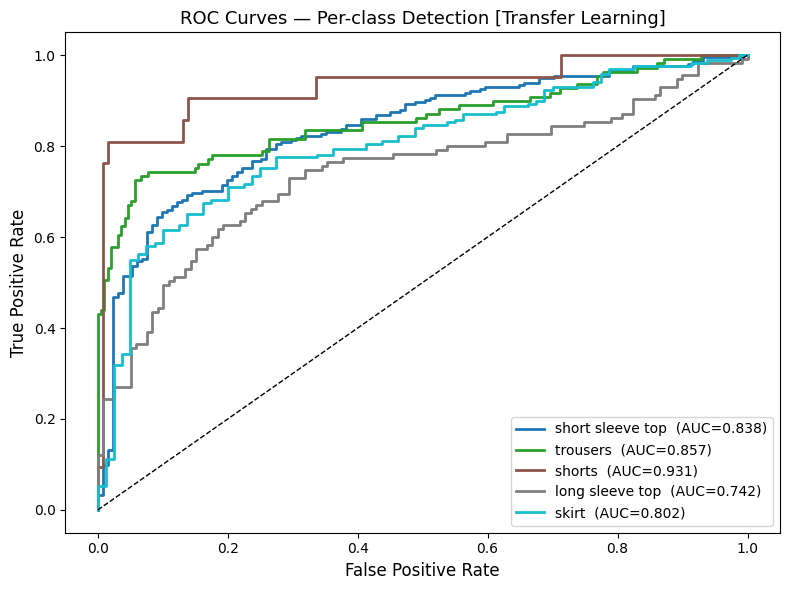

2026-03-31 07:08:28 | INFO     | roc_transfer_learning.png saved ✅


In [17]:
from sklearn.metrics import roc_curve, auc as sk_auc

def compute_roc(ckpt_path, n_images=400):
    model     = YOLO(ckpt_path)
    img_dir   = YOLO_DIR/'test'/'images'
    lbl_dir   = YOLO_DIR/'test'/'labels'
    img_paths = sorted(img_dir.glob('*.jpg'))[:n_images]
    scores    = defaultdict(lambda:{'conf':[],'label':[]})

    for ip in tqdm(img_paths, desc='  ROC sweep'):
        r = model.predict(ip, conf=0.01, verbose=False, save=False)
        if not r: continue
        r=r[0]
        lp=lbl_dir/(ip.stem+'.txt')
        if not lp.exists(): continue
        gt_set={int(l.split()[0]) for l in lp.read_text().strip().splitlines() if l}
        if r.boxes is None: continue
        for pc,cf in zip(r.boxes.cls.cpu().numpy().astype(int), r.boxes.conf.cpu().numpy()):
            scores[pc]['conf'].append(float(cf))
            scores[pc]['label'].append(1 if pc in gt_set else 0)

    fig, ax = plt.subplots(figsize=(8,6))
    colors  = plt.cm.tab10(np.linspace(0,1,len(TOP5_CAT_IDS)))

    log_section('ROC AUC PER CLASS (Detection)')
    auc_rows = []
    for i in range(len(TOP5_CAT_IDS)):
        c=scores[i]['conf']; l=scores[i]['label']
        if len(c)<10 or len(set(l))<2:
            logger.info(f'  ⚠️  {YOLO2NAME[i]:22s} — skipped (insufficient samples)')
            continue
        fpr,tpr,_=roc_curve(l,c)
        roc_auc = sk_auc(fpr,tpr)
        auc_rows.append((YOLO2NAME[i], f'{roc_auc:.4f}'))
        ax.plot(fpr,tpr,color=colors[i],
                label=f'{YOLO2NAME[i]}  (AUC={roc_auc:.3f})',linewidth=2)

    log_table(['Class', 'AUC'], auc_rows)

    ax.plot([0,1],[0,1],'k--',linewidth=1)
    ax.set_xlabel('False Positive Rate',fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curves — Per-class Detection [Transfer Learning]',fontsize=13)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('/kaggle/working/roc_transfer_learning.png',dpi=100)
    plt.show()
    logger.info('roc_transfer_learning.png saved ✅')

compute_roc(BEST_PT)

## Step 14 — Training Curves (Both Phases)

In [18]:
# import pandas as pd

# metrics_to_plot = [
#     ('metrics/mAP50(B)',  'Val mAP@0.5 (Box)'),
#     ('metrics/mAP50(M)',  'Val mAP@0.5 (Seg)'),
#     ('train/box_loss',    'Train Box Loss'),
#     ('train/seg_loss',    'Train Seg Loss'),
# ]
# fig, axes = plt.subplots(2, 2, figsize=(13,8))

# for ax, (col, title) in zip(axes.flatten(), metrics_to_plot):
#     offset = 0
#     for label, run_dir, color in [
#         ('Phase 1 (frozen)',    model_p1.trainer.save_dir, 'steelblue'),
#         ('Phase 2 (fine-tune)', model_p2.trainer.save_dir, 'darkorange'),
#     ]:
#         csv = Path(run_dir) / 'results.csv'
#         if csv.exists():
#             df = pd.read_csv(csv); df.columns = df.columns.str.strip()
#             if col in df.columns:
#                 vals = df[col].values
#                 epochs = range(offset, offset + len(vals))
#                 ax.plot(list(epochs), vals, color=color, linewidth=2, label=label)
#                 offset += len(vals)
#     ax.axvline(x=model_p1.trainer.epoch+1, color='gray', linestyle='--',
#                linewidth=1, label='Phase boundary')
#     ax.set_title(title); ax.set_xlabel('Epoch (cumulative)')
#     ax.legend(fontsize=7); ax.grid(alpha=0.3)

# plt.suptitle('Training Curves — Transfer Learning (Phase 1 + Phase 2)', fontsize=13)
# plt.tight_layout()
# plt.savefig('/kaggle/working/training_curves_tl.png', dpi=100)
# plt.show()
# logger.info('training_curves_tl.png saved ✅')

## Step 15 — Qualitative Predictions Visualisation

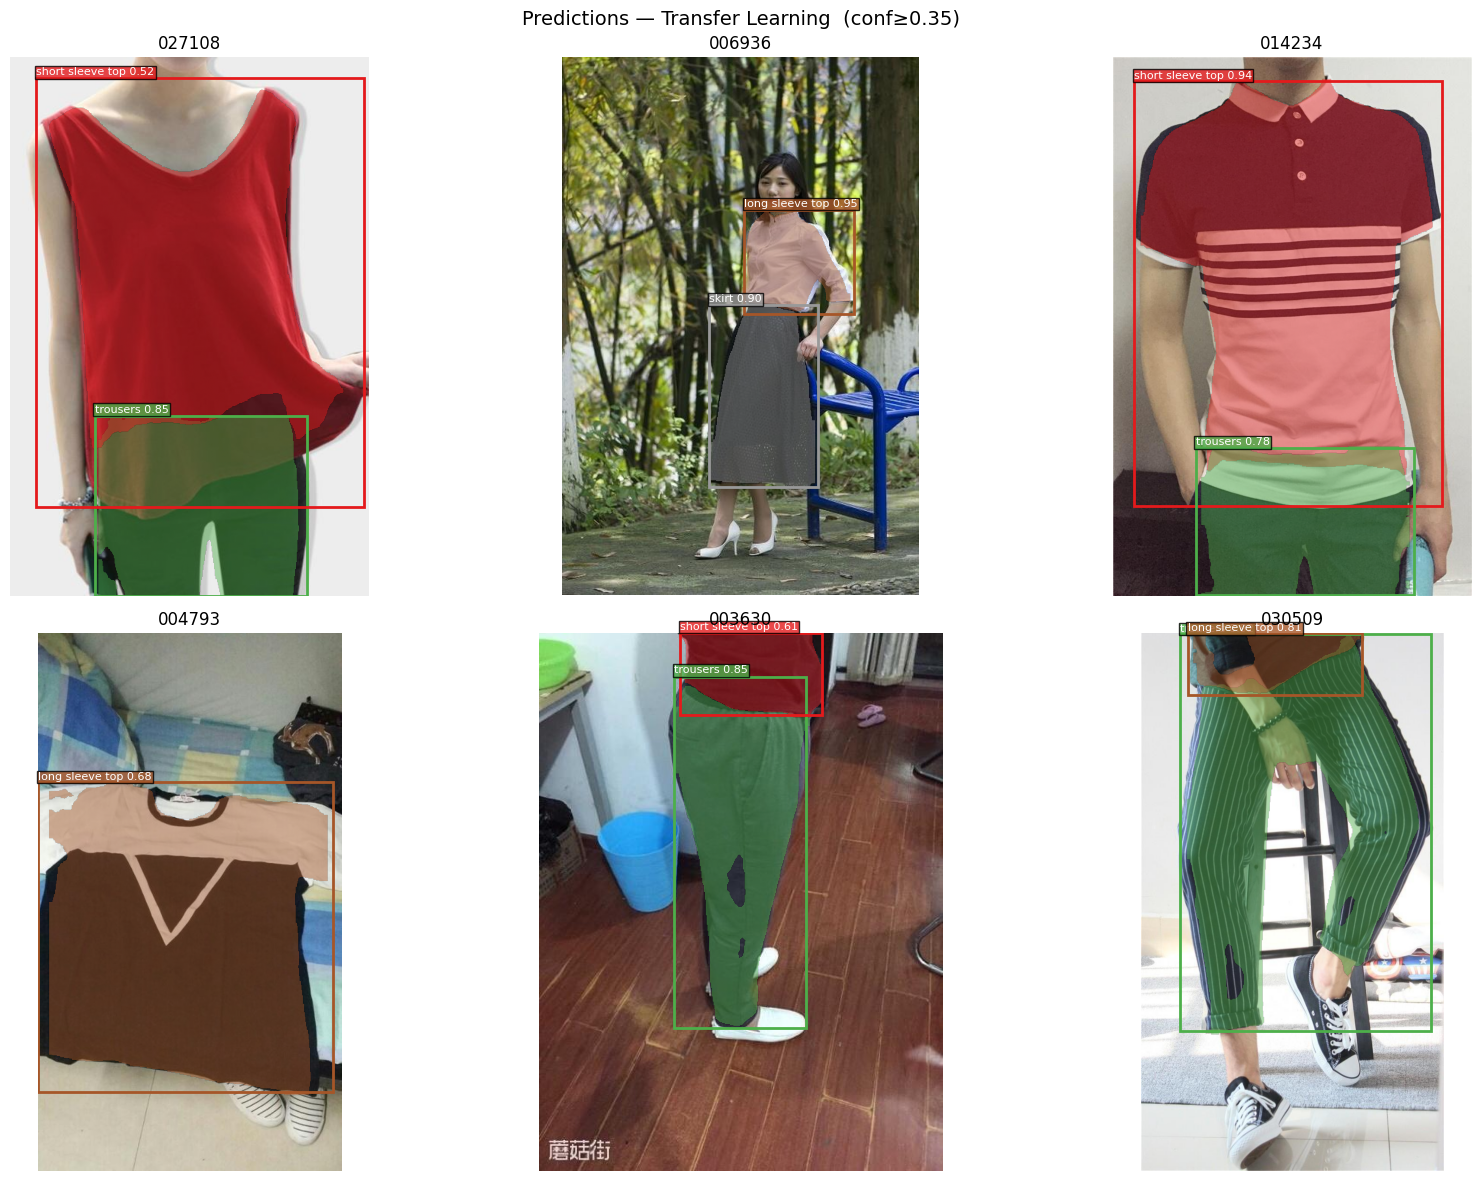

2026-03-31 07:08:49 | INFO     | /kaggle/working/predictions_transfer_learning.png saved ✅


In [19]:
def visualize_predictions(ckpt_path, title, n=6, conf=0.35):
    model     = YOLO(ckpt_path)
    img_dir   = YOLO_DIR/'test'/'images'
    img_paths = random.sample(sorted(img_dir.glob('*.jpg')), n)
    fig, axes = plt.subplots(2,3,figsize=(18,12))
    colors    = plt.cm.Set1(np.linspace(0,1,len(TOP5_CAT_IDS)))
    for ax, ip in zip(axes.flatten(), img_paths):
        r   = model.predict(ip, conf=conf, verbose=False, save=False)[0]
        img = np.array(Image.open(ip))
        ax.imshow(img)
        if r.masks is not None:
            for ci,mask in zip(r.boxes.cls.cpu().numpy().astype(int), r.masks.data.cpu().numpy()):
                mf=np.array(Image.fromarray((mask*255).astype(np.uint8)).resize(
                    (img.shape[1],img.shape[0]),Image.NEAREST))>128
                ov=np.zeros((*img.shape[:2],4)); ov[mf]=[*colors[ci][:3],0.45]; ax.imshow(ov)
        if r.boxes is not None:
            for box,ci,cv in zip(r.boxes.xyxy.cpu().numpy(),
                                  r.boxes.cls.cpu().numpy().astype(int),
                                  r.boxes.conf.cpu().numpy()):
                x1,y1,x2,y2=box
                ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                    linewidth=2,edgecolor=colors[ci][:3],facecolor='none'))
                ax.text(x1,y1-4,f'{YOLO2NAME[ci]} {cv:.2f}',color='white',fontsize=8,
                        bbox=dict(facecolor=colors[ci][:3],alpha=0.8,pad=1))
        ax.axis('off'); ax.set_title(ip.stem)
    plt.suptitle(f'Predictions — {title}  (conf≥{conf})', fontsize=14)
    plt.tight_layout()
    fname=f'/kaggle/working/predictions_{title.lower().replace(" ","_")}.png'
    plt.savefig(fname,dpi=100); plt.show()
    logger.info(f'{fname} saved ✅')

visualize_predictions(BEST_PT, 'Transfer Learning')

## Step 16 — Export Model for HuggingFace Upload

In [20]:
shutil.copy(BEST_PT, '/kaggle/working/best_tl.pt')
YOLO(BEST_PT).export(format='onnx', imgsz=640, dynamic=True)

log_section('ALL DONE')
logger.info(f'Completed at  : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
logger.info(f'Best weights  : /kaggle/working/best_tl.pt')
#logger.info(f'Phase 1 dir   : {model_p1.trainer.save_dir}')
logger.info(f'Phase 2 dir   : {model_p2.trainer.save_dir}')
logger.info(f'Log file      : /kaggle/working/training_log_tl.txt')
logger.info('Output files:')
for f in sorted(Path('/kaggle/working').glob('*.png')):
    logger.info(f'  {f}')

print('\n🎉 Files ready:')
print('   /kaggle/working/best_tl.pt')
print('   /kaggle/working/label_map.json')
print('   /kaggle/working/training_log_tl.txt')

Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8s-seg summary (fused): 86 layers, 11,781,535 parameters, 0 gradients, 39.9 GFLOPs

PyTorch: starting from '/kaggle/working/runs/tl_phase2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 41, 8400), (1, 32, 160, 160)) (22.7 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 258ms
 Downloaded onnxruntime-gpu
Prepared 2 packages in 3.12s
Installed 2 packages in 13ms
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 4.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: sl